# Teen Mental Health Analysis

This notebook documents a simple machine learning workflow to predict whether a teen is depressed or not using behavioral, social, and lifestyle features.

## Objective
The goal is to predict `depression_label` and compare a few baseline modeling choices on an imbalanced dataset.

## Dataset Context
The analysis uses features related to:
- demographics
- social media usage
- sleep habits
- academic performance
- physical activity
- anxiety, stress, and addiction indicators

A key challenge in this project is class imbalance, which affects how well the model detects depressed teens.

## 1. Load the Dataset

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_data(file_path):
    data = pd.read_csv(file_path)
    return data

path = 'Teen_Mental_Health_Dataset.csv'
data = load_data(path)

data.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.900,Instagram,7.400,2.900,3.010,1.500,low,2,2,1,0
1,19,female,1.900,TikTok,8.000,2.900,3.220,0.800,high,8,1,10,0
2,17,female,1.300,Instagram,7.600,0.500,3.920,0.000,high,2,4,2,0
3,15,male,7.400,TikTok,6.900,1.600,3.480,0.800,medium,1,7,9,0
4,15,female,4.700,Both,4.900,3.000,2.370,1.400,medium,3,5,2,0


## 2. Initial Data Inspection

Before training any model, the dataset is reviewed to understand:
- the available columns
- the data types
- the summary statistics
- whether there are missing values

This step helps confirm that the data is usable and gives a first understanding of the variables.

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [19]:
data.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,"1,200.000","1,200.000","1,200.000","1,200.000","1,200.000","1,200.000","1,200.000","1,200.000","1,200.000","1,200.000"
mean,15.928,4.537,6.449,1.740,2.990,1.015,5.446,5.637,5.565,0.026
std,2.022,2.030,1.443,0.717,0.577,0.582,2.903,2.859,2.831,0.159
min,13.000,1.000,4.000,0.500,2.000,0.000,1.000,1.000,1.000,0.000
25%,14.000,2.800,5.200,1.100,2.500,0.500,3.000,3.000,3.000,0.000
50%,16.000,4.500,6.500,1.800,2.990,1.000,5.000,6.000,6.000,0.000
75%,18.000,6.300,7.600,2.400,3.480,1.500,8.000,8.000,8.000,0.000
max,19.000,8.000,9.000,3.000,4.000,2.000,10.000,10.000,10.000,1.000


In [20]:
data.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

## 3. Correlation Analysis

Categorical features are encoded using `get_dummies`, then a correlation matrix is plotted to better understand the relationships between features and the target.

This step helps highlight which variables seem most associated with depression.

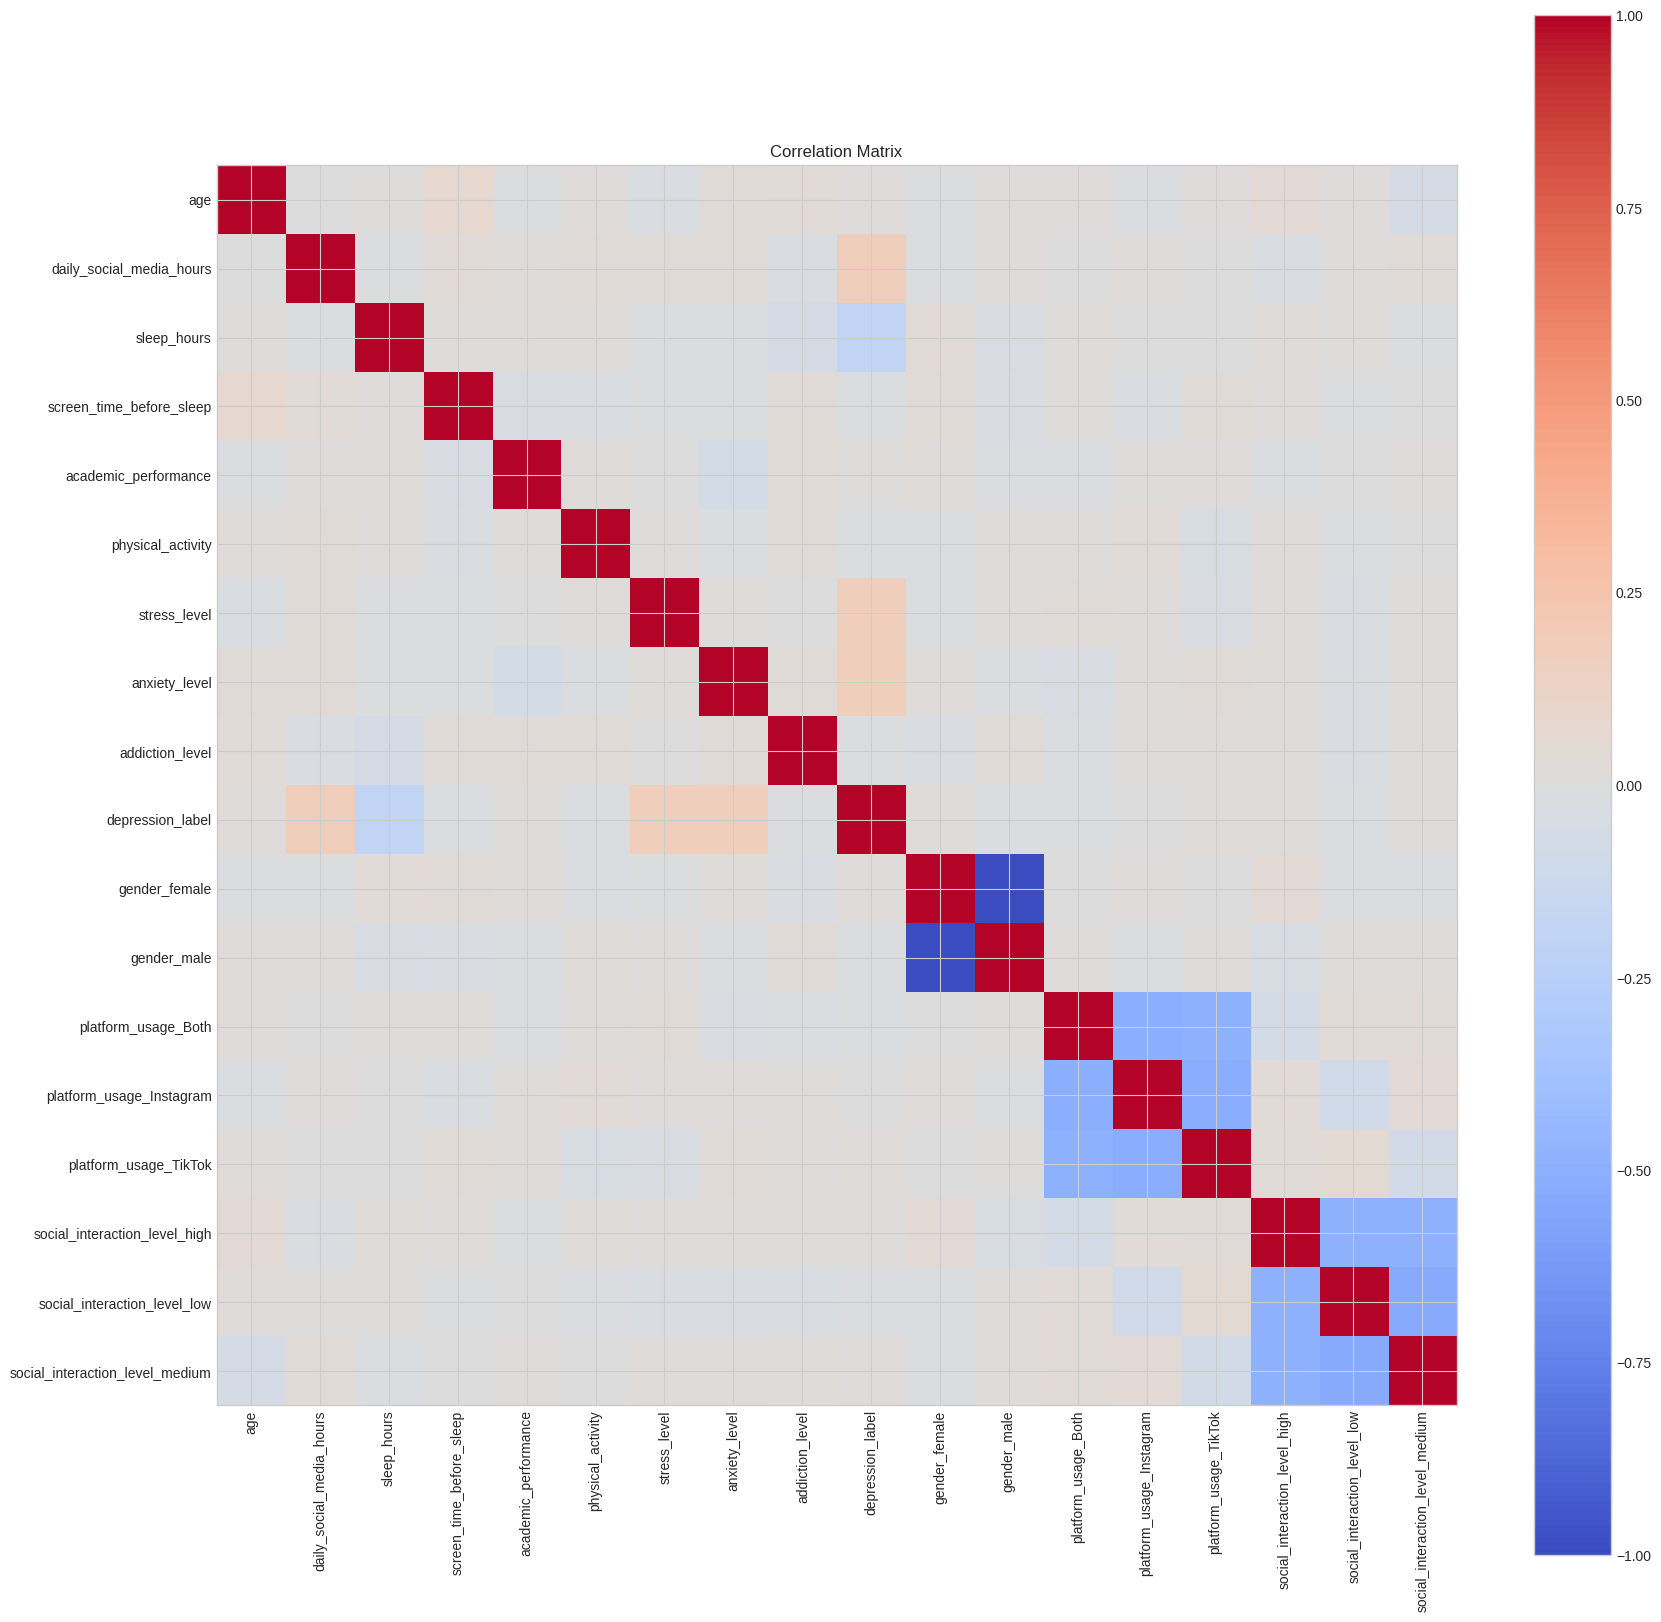

In [21]:
data_encoded = pd.get_dummies(data, columns=['gender', 'platform_usage','social_interaction_level'])

correlation_matrix = data_encoded.corr()
plt.figure(figsize=(20, 20))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Correlation Matrix')
plt.show()

From this analysis, anxiety, stress, and daily social media hours appear to be among the strongest signals related to `depression_label`.

## 4. Baseline Logistic Regression

Some dummy variables contain redundant information because of perfect correlation. To reduce that redundancy, one category from selected encoded groups is removed before training the model.

The first model tested is logistic regression.

In [22]:
data_encoded.drop(columns=['gender_male', 'social_interaction_level_low'], inplace=True)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X = data_encoded.drop('depression_label', axis=1)
y = data_encoded['depression_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       234
           1       0.67      0.67      0.67         6

    accuracy                           0.98       240
   macro avg       0.83      0.83      0.83       240
weighted avg       0.98      0.98      0.98       240

[[232   2]
 [  2   4]]


/home/bakemono/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 5. Handling Class Imbalance

The first results show that the model performs better on the majority class than on the minority class. Since the dataset is imbalanced, this is expected.

To address that issue, a second logistic regression model is trained with `class_weight='balanced'`.

In [23]:
model_balanced = LogisticRegression(class_weight='balanced')

model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))


              precision    recall  f1-score   support

           0       1.00      0.95      0.97       234
           1       0.29      0.83      0.43         6

    accuracy                           0.95       240
   macro avg       0.64      0.89      0.70       240
weighted avg       0.98      0.95      0.96       240

[[222  12]
 [  1   5]]


/home/bakemono/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 6. Threshold Tuning

After improving recall with class balancing, the next idea is to adjust the prediction threshold and see whether a lower cutoff improves the classification of depressed teens.

In [24]:
y_prob = model_balanced.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.3).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.94      0.96       234
           1       0.25      0.83      0.38         6

    accuracy                           0.93       240
   macro avg       0.62      0.88      0.67       240
weighted avg       0.98      0.93      0.95       240

[[219  15]
 [  1   5]]


## 7. Model Comparison

A random forest classifier is tested as an alternative model and compared with logistic regression.

In [25]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(class_weight='balanced')
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.17      0.29         6

    accuracy                           0.98       240
   macro avg       0.99      0.58      0.64       240
weighted avg       0.98      0.98      0.97       240

[[234   0]
 [  5   1]]


## 8. Feature Importance and Feature Engineering

Once the preferred model is identified, feature importance is reviewed to understand which variables contribute most to prediction.

A small feature engineering attempt is also made to check whether combining some variables improves performance.

gender_female                      2.158
daily_social_media_hours           1.264
anxiety_level                      1.228
social_interaction_level_medium    1.103
stress_level                       0.995
academic_performance               0.289
addiction_level                    0.029
screen_time_before_sleep           0.001
platform_usage_Both               -0.148
age                               -0.190
social_interaction_level_high     -0.438
platform_usage_TikTok             -0.700
physical_activity                 -1.147
platform_usage_Instagram          -1.478
sleep_hours                       -2.848
dtype: float64


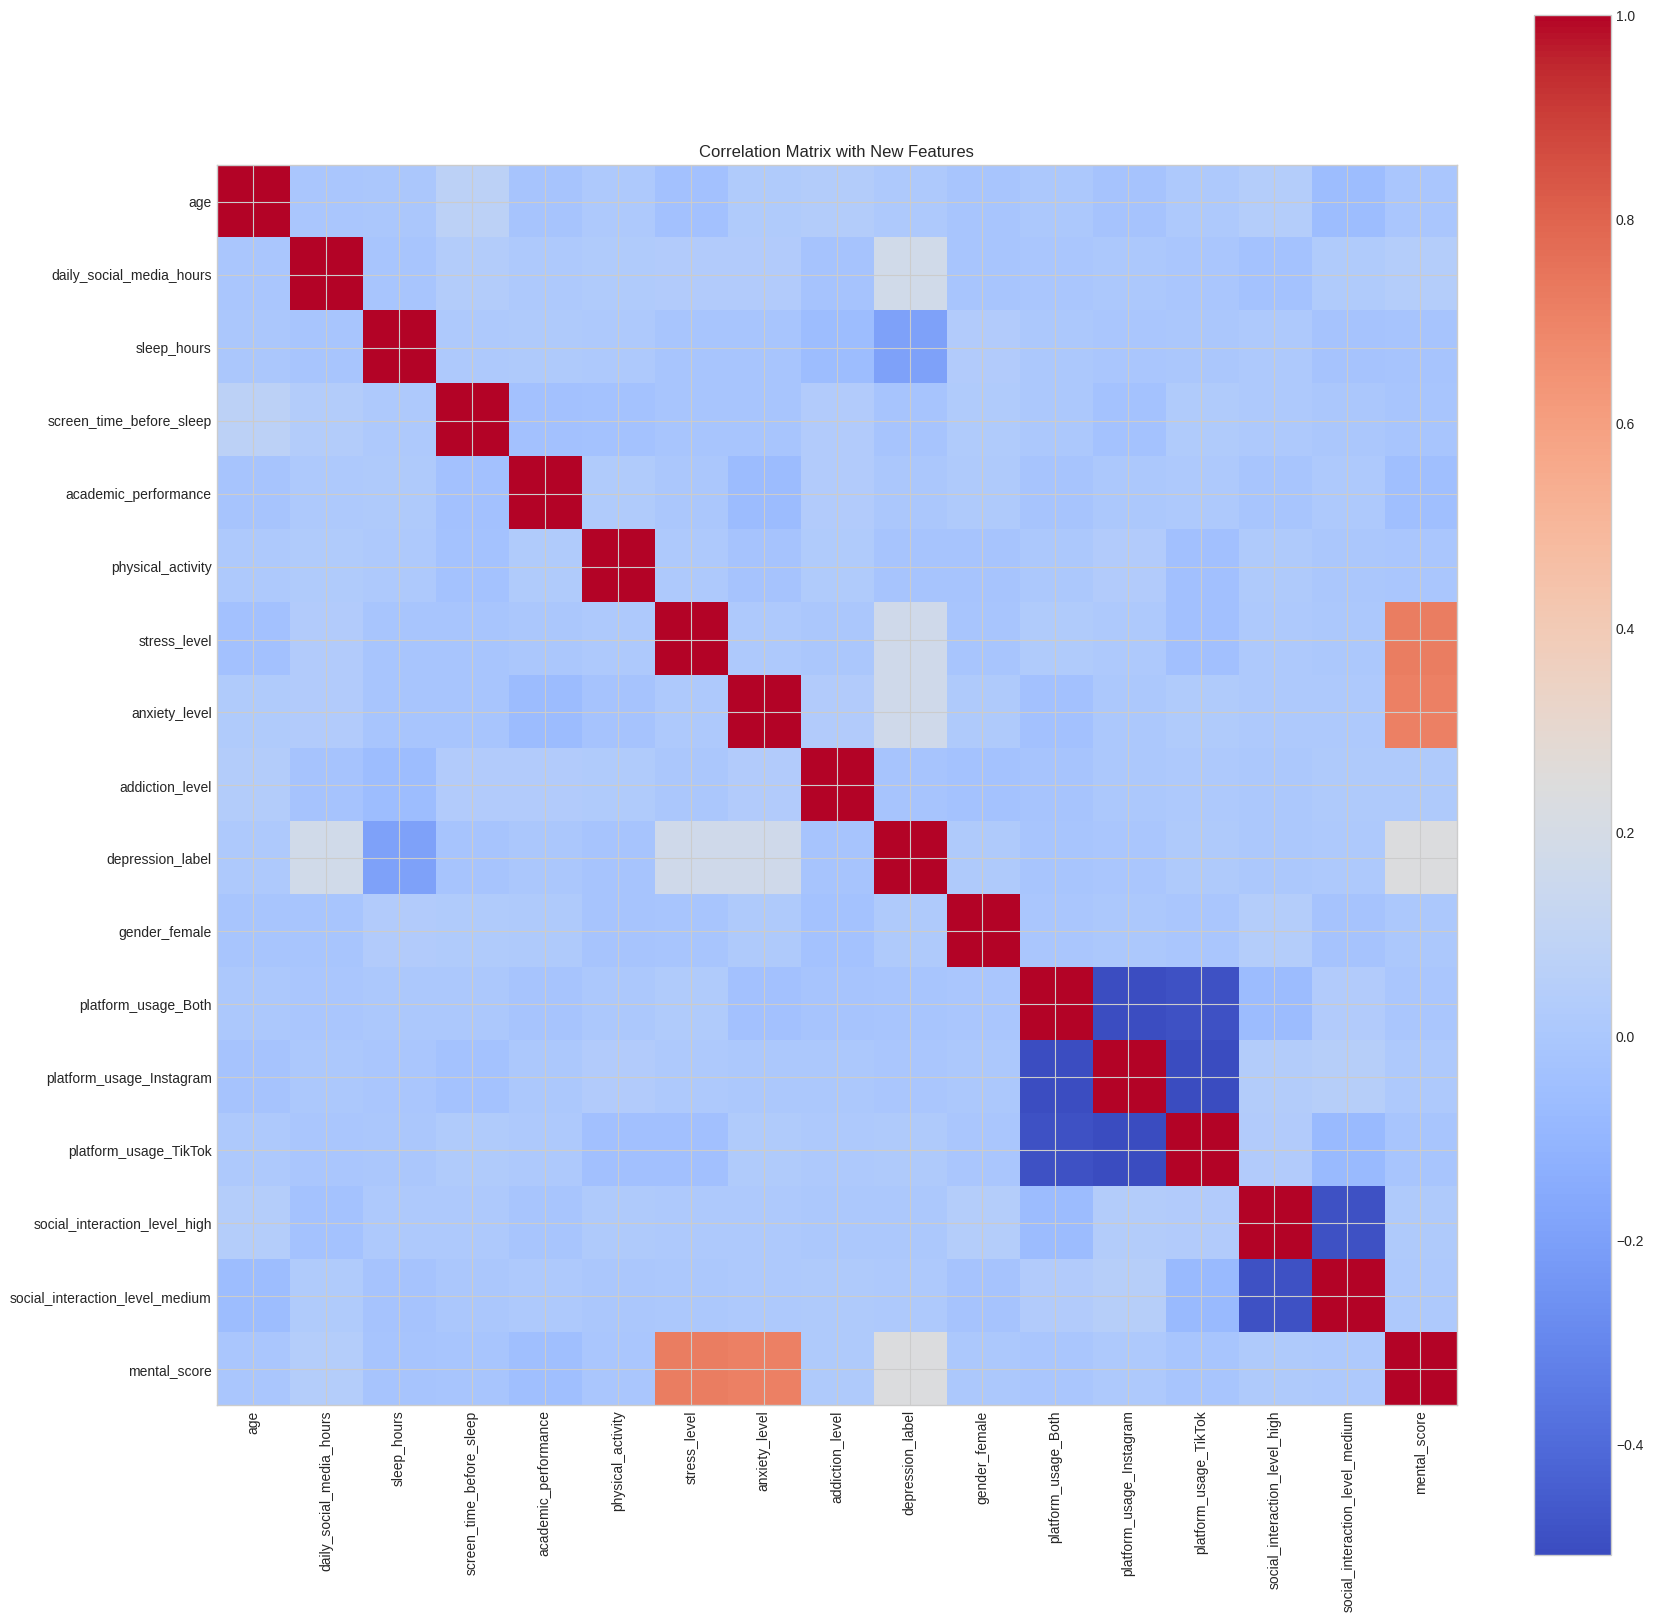

In [26]:
feature_importance = pd.Series(model_balanced.coef_[0], index=X.columns)
feature_importance.sort_values(ascending=False, inplace=True)
print(feature_importance)


data_encoded['mental_score'] = data_encoded['anxiety_level'] + data_encoded['stress_level']
data['total_screen'] = data['daily_social_media_hours'] + data['screen_time_before_sleep']

correlation_matrix = data_encoded.corr()
plt.figure(figsize=(20, 20))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Correlation Matrix with New Features')
plt.show()

## 9. Final Check After Feature Engineering

The balanced logistic regression model is trained again after adding the engineered feature to verify whether the additional information improves performance.

In [27]:
X = data_encoded.drop('depression_label', axis=1)
y = data_encoded['depression_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.95      0.97       234
           1       0.29      0.83      0.43         6

    accuracy                           0.95       240
   macro avg       0.64      0.89      0.70       240
weighted avg       0.98      0.95      0.96       240

[[222  12]
 [  1   5]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.96       234
           1       0.25      0.83      0.38         6

    accuracy                           0.93       240
   macro avg       0.62      0.88      0.67       240
weighted avg       0.98      0.93      0.95       240

[[219  15]
 [  1   5]]


/home/bakemono/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Conclusion

This notebook shows a complete baseline workflow for predicting teen depression:
- load and inspect the dataset
- encode categorical features
- analyze feature correlations
- train and evaluate logistic regression
- address class imbalance
- compare with random forest
- try simple feature engineering

The main takeaway is that the dataset imbalance makes the minority class harder to predict. In this workflow, logistic regression with class balancing remains the preferred model. A likely next step would be to rebalance the dataset or test more advanced methods designed for imbalanced classification.